In [1]:
from langgraph.graph import StateGraph, START
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools import tool
from langchain_community.vectorstores import FAISS

d:\Lang_Graph_Concepts\langgraphvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
C:\Users\ABHIMANU\AppData\Local\Temp\ipykernel_24000\1033308873.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [2]:
load_dotenv()

True

In [3]:
loader = PyPDFLoader("../islr.pdf")
docs = loader.load()

In [4]:
len(docs)

441

In [5]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [30]:
len(chunks)

1308

In [31]:
from langchain_openai import OpenAIEmbeddings

In [32]:
embedding = OpenAIEmbeddings(model="text-embedding-3-small")
vs = FAISS.from_documents(chunks,embedding)

In [33]:
vs

In [34]:
retriever = vs.as_retriever(search_type='similarity',search_kwargs={"k":4})

In [35]:
result = retriever.invoke('what is linear regression.')
for r in result:
    print(r.page_content)
    print("*"*80)

3
Linear Regression
This chapter is about linear regression, a very simple approach for
supervised learning. In particular, linear regression is a useful tool for pre-
dicting a quantitative response. Linear regression has been around for a
long time and is the topic of innumerable textbooks. Though it may seem
somewhat dull compared to some of the more modern statistical learning
approaches described in later chapters of this book, linear regression is still
a useful and widely used statistical learning method. Moreover, it serves
as a good jumping-oﬀ point for newer approaches: as we will see in later
chapters, many fancy statistical learning approaches can be seen as gener-
alizations or extensions of linear regression. Consequently, the importance
of having a good understanding of linear regression before studying more
complex learning methods cannot be overstated. In this chapter, we review
some of the key ideas underlying the linear regression model, as well as the
**************

In [45]:
@tool
def rag_tool(query):
    """
    Retrieve the relevent information from the PDF document.
    Use this tool when the user asks for factual/conceptual questions
    that might be answered from the stored documents
    """
    res = retriever.invoke(query)

    context = [doc.page_content for doc in res]
    metadata = [doc.metadata for doc in res]

    return "\n\n".join([doc.page_content for doc in res])
    #Groq's function-calling parser expects tools to return a simple string (or basic stringified text) rather than raw dictionary/list structures. When the graph passed that dictionary output back into the model, Groq failed to parse it properly and threw a BadRequestError.
    # return {
    #     "query":query,
    #     "context":context,
    #     "metadata":metadata
    # }

In [46]:
import os
llm = ChatGroq(
    model="llama-3.1-8b-instant", 
    api_key=os.getenv("GROQ_API_KEY"), #type:ignore
    temperature=0.4
)

In [47]:
tools = [rag_tool]
llm_with_tool = llm.bind_tools(tools)

In [48]:
class State(TypedDict):
    messages : Annotated[list[str],add_messages]

In [49]:
def chat_node(state:State):
    messages = state['messages']
    response = llm_with_tool.invoke(messages)
    return {'messages':[response]}

In [50]:
tool_node = ToolNode(tools)

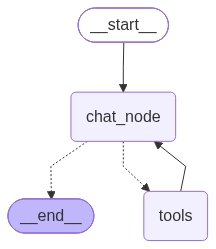

In [51]:
graph = StateGraph(State)

graph.add_node("chat_node",chat_node)
graph.add_node("tools",tool_node)

graph.add_edge(START,"chat_node")
graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge("tools","chat_node")

chatbot = graph.compile()

chatbot

In [52]:
result = chatbot.invoke({'messages':[HumanMessage(content="using the pdf notes tell me whats linear regression is in easy words.")]})#type:ignore

In [56]:
print(result['messages'][0].content)

using the pdf notes tell me whats linear regression is in easy words.
